                                       Time Series Price Prediction using ARIMA

# Problem Statement

The objective is to forecast average monthly prices for the next 12 months using historical time-series data.

## 1.Data Cleaning

In [74]:
import pandas as pd
df=pd.read_csv("price_data.csv")
print(df)

           date  avg_monthly_price
0    2005-01-01               5500
1    2005-02-01               5476
2    2005-03-01               5466
3    2005-04-01               5487
4    2005-05-01               5876
..          ...                ...
244  2025-05-01              14263
245  2025-06-01              14263
246  2025-07-01              16000
247  2025-08-01              15025
248  2025-09-01              15750

[249 rows x 2 columns]


In [75]:
print(df.head())

         date  avg_monthly_price
0  2005-01-01               5500
1  2005-02-01               5476
2  2005-03-01               5466
3  2005-04-01               5487
4  2005-05-01               5876


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               249 non-null    object
 1   avg_monthly_price  249 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.0+ KB


In [77]:
#convert date column

df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               249 non-null    datetime64[ns]
 1   avg_monthly_price  249 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.0 KB


In [78]:
#handle missing values

print(df.isnull().sum())

date                 0
avg_monthly_price    0
dtype: int64


In [79]:
#Find duplicates

duplicates = df[df.duplicated()]

print("Duplicate rows:")
print(duplicates)

Duplicate rows:
Empty DataFrame
Columns: [date, avg_monthly_price]
Index: []


## 2.Outliers & Anomalies Detection

In [80]:
#IQR method

Q1=df["avg_monthly_price"].quantile(0.25)
Q3=df["avg_monthly_price"].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

print("Lower:",lower_bound)
print("Upper:",upper_bound)

Lower: 633.0
Upper: 15273.0


In [81]:
outliers=df[(df["avg_monthly_price"]<lower_bound)|(df["avg_monthly_price"]>upper_bound)]

print("Outliers:")
print(outliers)

Outliers:
          date  avg_monthly_price
227 2023-12-01              16163
231 2024-04-01              15863
232 2024-05-01              15863
233 2024-06-01              15488
234 2024-07-01              15294
246 2025-07-01              16000
248 2025-09-01              15750


Outliers were detected using the Interquartile Range (IQR) method. A few high price values were identified as outliers. However, these values were not removed because they represent genuine variations in price over time rather than data errors. Since this is time-series data, such variations may indicate real market trends or price increases. Therefore, the outliers were retained to preserve the integrity of the dataset and allow the model to learn actual market behavior.

## 3. Anomalies Detection

In [82]:
#monthly difference

df["price_change"]=df["avg_monthly_price"].diff()

print(df["price_change"])

0         NaN
1       -24.0
2       -10.0
3        21.0
4       389.0
        ...  
244       0.0
245       0.0
246    1737.0
247    -975.0
248     725.0
Name: price_change, Length: 249, dtype: float64


In [83]:
print(df["price_change"].describe())

count     248.000000
mean       41.330645
std       840.493254
min     -5793.000000
25%      -185.500000
50%         0.000000
75%       222.000000
max      7763.000000
Name: price_change, dtype: float64


In [84]:
#set Threshold

threshold=df["price_change"].std()*2

print(threshold)

1680.9865085408342


In [85]:
#Find anamolies

anomolies=df[abs(df["price_change"])>threshold]

print("Anomolies:")
print(anomolies)

Anomolies:
          date  avg_monthly_price  price_change
16  2006-05-01               6000        2500.0
106 2013-11-01              11016        3272.0
197 2021-06-01               5070       -5793.0
227 2023-12-01              16163        7763.0
228 2024-01-01              13488       -2675.0
242 2025-03-01              14188        2875.0
246 2025-07-01              16000        1737.0


Anomalies were detected by analyzing month-to-month changes in price using the difference method. A threshold based on twice the standard deviation was used to identify unusually large changes. Several anomalies were found, representing sudden increases and decreases in price. These anomalies were retained because they reflect genuine market fluctuations and are important for capturing real trends in time-series data.

## 4.Model Training-Train Linear Regression

In [86]:
from sklearn.linear_model import LinearRegression

In [87]:
df=df.sort_values('date')

df['time_index']=range(len(df))

X=df[['time_index']]
y=df['avg_monthly_price']

lr_model=LinearRegression()

lr_model.fit(X,y)

df['lr_pred']=lr_model.predict(X)

print(df.head())

        date  avg_monthly_price  price_change  time_index      lr_pred
0 2005-01-01               5500           NaN           0  5151.754988
1 2005-02-01               5476         -24.0           1  5174.070606
2 2005-03-01               5466         -10.0           2  5196.386223
3 2005-04-01               5487          21.0           3  5218.701841
4 2005-05-01               5876         389.0           4  5241.017458


The Linear Regression model captures the overall upward trend in the data. However, it fails to accurately predict sudden spikes and fluctuations in prices, as it assumes a linear relationship between time and price. Therefore, it is used as a baseline model, and more advanced models like ARIMA are required for better accuracy.

## 5.ARIMA (Main Model)

In [88]:
import warnings

warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA

df=df.sort_values('date')

df.set_index('date',inplace=True)

model=ARIMA(df['avg_monthly_price'],order=(1,1,1))

model_fit=model.fit()

In [89]:
summary_df = pd.DataFrame({
    "Metric": ["Model", "Observations"],
    "Value": [
        "ARIMA(1,1,1)",
        len(df)
    ]
})

print(summary_df)

         Metric         Value
0         Model  ARIMA(1,1,1)
1  Observations           249



An ARIMA(1,1,1) model was trained using the historical monthly price data. The model uses one previous observation (AR=1), first-order differencing (d=1), and one previous prediction error (MA=1) to capture trends and fluctuations in the time series.

In [90]:
#Generate Predictions
df['arima_pred'] = model_fit.predict(start=1, end=len(df)-1)
print(df[['avg_monthly_price', 'arima_pred']].head())

            avg_monthly_price   arima_pred
date                                      
2005-01-01               5500          NaN
2005-02-01               5476  5425.898497
2005-03-01               5466  5536.076954
2005-04-01               5487  5418.183476
2005-05-01               5876  5524.682674


The ARIMA model generated predictions for the historical data. The first prediction is missing because differencing requires a previous observation. The predicted values closely follow the actual price values.

## 6. Model Evaluation (MAE & RMSE)

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Drop NaN values
df_eval = df.dropna()

# Linear Regression metrics
mae_lr = mean_absolute_error(df_eval['avg_monthly_price'], df_eval['lr_pred'])
rmse_lr = np.sqrt(mean_squared_error(df_eval['avg_monthly_price'], df_eval['lr_pred']))

# ARIMA metrics
mae_arima = mean_absolute_error(df_eval['avg_monthly_price'], df_eval['arima_pred'])
rmse_arima = np.sqrt(mean_squared_error(df_eval['avg_monthly_price'], df_eval['arima_pred']))

print("Linear Regression → MAE:", mae_lr, "RMSE:", rmse_lr)
print("ARIMA → MAE:", mae_arima, "RMSE:", rmse_arima)

Linear Regression → MAE: 1795.4798774995925 RMSE: 2298.7362810688137
ARIMA → MAE: 411.06161870204556 RMSE: 838.6107803978135


Model performance was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). The ARIMA model achieved an MAE of 411.06 and an RMSE of 838.61, indicating good forecasting accuracy. The lower error values compared to Linear Regression demonstrate that ARIMA is more suitable for this time-series forecasting task.

## 7.Forecast Next 12 Months

In [92]:
#Generate 12-Month Forecast
forecast = model_fit.forecast(steps=12)

print(forecast)

2025-10-01    15652.870430
2025-11-01    15733.712329
2025-12-01    15666.426819
2026-01-01    15722.429213
2026-02-01    15675.817868
2026-03-01    15714.612950
2026-04-01    15682.323420
2026-05-01    15709.198315
2026-06-01    15686.830075
2026-07-01    15705.447382
2026-08-01    15689.952014
2026-09-01    15702.848961
Freq: MS, Name: predicted_mean, dtype: float64


In [93]:
#Create Future Dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

In [94]:
#Create Forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Price': forecast.values
})

print(forecast_df)

         Date  Forecasted_Price
0  2025-10-01      15652.870430
1  2025-11-01      15733.712329
2  2025-12-01      15666.426819
3  2026-01-01      15722.429213
4  2026-02-01      15675.817868
5  2026-03-01      15714.612950
6  2026-04-01      15682.323420
7  2026-05-01      15709.198315
8  2026-06-01      15686.830075
9  2026-07-01      15705.447382
10 2026-08-01      15689.952014
11 2026-09-01      15702.848961


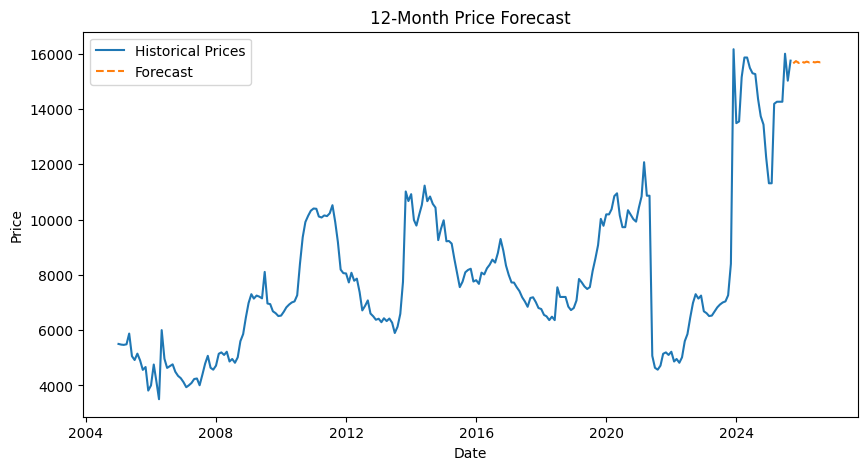

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df.index, df['avg_monthly_price'], label='Historical Prices')

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecasted_Price'],
    label='Forecast',
    linestyle='--'
)

plt.title('12-Month Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

## 8.Actions Based on Predicted Price Changes

Based on the forecasted prices, the company can take proactive actions to improve profitability and reduce risk. If prices are expected to increase, the company can purchase inventory in advance, secure supplier contracts at current rates, and adjust product pricing strategies. If prices are expected to decrease, the company can reduce inventory levels, avoid overstocking, and plan promotional campaigns to maintain sales. Using forecasted prices allows the company to make informed decisions rather than reacting after price changes occur.

## 9.How to Determine Whether the Actions Are Effective

The effectiveness of the forecasting-based decisions can be evaluated by comparing business performance before and after implementation. Actual prices can be compared with forecasted prices to measure forecasting accuracy. Business metrics such as revenue, profit, inventory turnover, stock shortages, and excess inventory levels can also be monitored. If forecasting accuracy remains high and operational performance improves, it indicates that the actions taken based on the model predictions are effective.

## 10.Conclusion

This project focused on forecasting average monthly prices using historical time-series data. The dataset was cleaned by checking for missing values, duplicate records, outliers, and anomalies. Linear Regression and ARIMA models were developed and evaluated using MAE and RMSE metrics. The results showed that ARIMA significantly outperformed Linear Regression, achieving lower prediction errors and providing more accurate forecasts. Using the selected ARIMA model, monthly prices were forecasted for the next 12 months. These forecasts can help organizations make informed decisions related to inventory management, procurement planning, pricing strategies, and budgeting. Overall, the project demonstrates how time-series forecasting can support data-driven business decision-making